In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,accuracy_score
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv("diabetes 1.csv", usecols=[0, 1, 2, 3, 4, 5, 6, 7, 8])

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]
Scaler = StandardScaler()
X = Scaler.fit_transform(X)

In [7]:
X = np.asarray(X)
y = np.asarray(y).reshape(-1, 1)

In [8]:
X.shape

(768, 8)

In [9]:
y.shape

(768, 1)

In [10]:
#Activation functions

def sigmoid(z):
    s = 1/ (1 + np.exp(-z))
    return s

In [23]:
def logiLGD(X, y, lr, epoch):

    m = X.shape[0]
    nx = X.shape[1]
    
    np.random.seed(123)
    
    w = np.random.randn(nx, 1)
    b = 2.0

    cost_history = []

    for i in range(epoch):
        h = np.dot(X, w) + b
        a = sigmoid(h)
        
        cost = - (1 / m) * np.sum(y * np.log(a+1e-15) + (1 - y) * np.log(1 - a+1e-15))
        error = a - y
        dw = (X.T @ error) / m
        db = np.sum(error) / m
        w = w - lr * dw
        b = b - lr * db
        cost_history.append(cost)

        if i % 1000 == 0:
            print(f"iteration {i:4d} cost = {cost:.6f}")
        plt.plot(cost_history)
    return w, b
    print(w, b)

iteration    0 cost = 2.049427
iteration 1000 cost = 0.470993
iteration 2000 cost = 0.470993
iteration 3000 cost = 0.470993
iteration 4000 cost = 0.470993


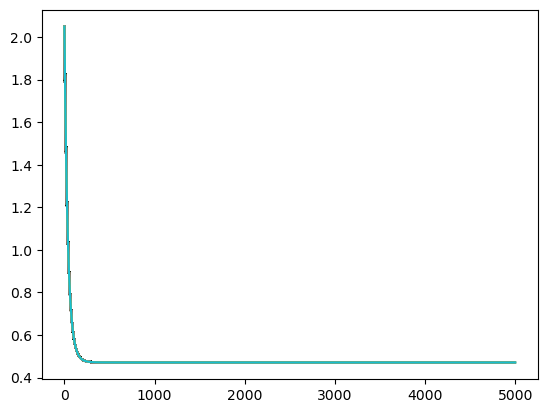

In [34]:
w, b = logiLGD(X, y, 0.1, 5000)

In [35]:
def predict(X, w, b):
    h = X @ w + b
    a = sigmoid(h)
    return (a > 0.5).astype(int)

In [36]:
y_pred = predict(X, w, b)

In [37]:
confm = accuracy_score(y, y_pred)
confm

0.7825520833333334

In [38]:
X.shape

(768, 8)